\title{Assignment 1}
\author{Thomas Seeberg Christiansen}
\date{\today}

\maketitle

# Problem 1

## a) NLP

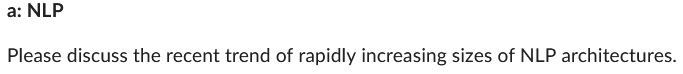

## b) Transfer Learning

The domains and tasks can be defined as the following. The Source and Target domains are in this case a step counter as the "optimization parameter". The tasks are, however, different between the Source and the Target. The Source tasks is monitoring exercise in healthy people and the Target tasks is indicating recovery progression in a patient. 
$$
\begin{aligned}
    D_S&: \text{Step Counter} & T_S&: \text{Monitor exercise} \\
    D_T&: \text{Step Counter} & T_T&: \text{Indicate recovery progression} 
\end{aligned}
$$
In conclusion, we are dealing with inductive transfer learning, since we see $D_S=D_T$ and $T_S\neq T_T$.

## c) Attention

Dot product attention is defined as $a_{ij}=s_{i-1}^T h_j$, where $h$ are our, in this case, 4 hidden states and $s_{i-1}$ being our previous decoder activation. Hence:
$$
\begin{aligned}
    h_1 &= [0,1,4] \\
    h_2 &= [-1,1,2] \\
    h_3 &= [1,1,1] \\
    h_4 &= [2,1,1] \\
    s_{i-1} &= [0.1,1,-2]^T
\end{aligned}
$$
The attention-context vector is found by $c_i=\sum_j \alpha_{ij}h_j$, with the attention weight as $\alpha_{ij}=\frac{e^{a_{ij}}}{\sum_k e^{a_{ik}}}$. This can be calculated using the following Python code:

In [2]:
import numpy as np
# Previous decoder activation
s_p1 = np.array([0.1,1,-2]).T

# Hidden states
h = np.array([[0,1,4],[-1,1,2],[1,1,1],[2,1,1]]).T

# Dot product attention
a_ij = np.dot(s_p1,h)

# Attention weight
alpha_ij = np.exp(a_ij)/(np.sum(np.exp(a_ij)))

# Attention-context vector
c_i = np.matmul(alpha_ij,h.T)
print(f'c_i = {c_i}')

c_i = [1.39731088 1.         1.05298479]


Thus, the resulting attention context vector is $c_i=[1.39,1.,1.05]$

## d) Transformers

We lose all positional features from the input sequence when using transformers, due to the multi-head attention effecient way of parallelizing the network. This means if we pass a spoken langauge sentence through, the network wouldn't know the order of anything and the sentences would lose its meaning. The solution is encoding positional information onto each token with a unique position related signal. It adds a tensor with a specific pattern based on sine and cosine functions which captures the relative distance, or relation, to other inputs. This means the network can recognize the order of the words and the distance between them, effectively retaining sequence structures. 

## e) Bounding Box Detection

The mean average precision, mAP, is the mean of the average precision, AP, of all the classes. Its defined by:
$$AP=\sum_n(R_{n+1}-R_nP)(R_{n+1})$$
$$mAP=(AP_{dog}+AP_{cat})/2$$
For this, we need to sort the prediction scores, calculate the precision and recall, calculate the AP, and finally find the mAP.

In [4]:
# Data for cats
cat_det = np.array([1, 0, 1, 0, 1])  # 1 for TP, 0 for FP
pred_scores_cat = np.array([0.7, 0.3, 0.5, 0.6, 0.5])
total_cats = 3  # total ground truth positives for cats

# Data for dogs
dog_det = np.array([0, 1, 1, 0, 1, 1])  # 1 for TP, 0 for FP
pred_scores_dog = np.array([0.4, 0.3, 0.9, 0.5, 0.6, 0.7])
total_dogs = 4  # total ground truth positives for dogs

# Function to calculate Average Precision (AP)
def calculate_ap(detections, scores, total_positives):
    # Sort detections by prediction scores in descending order
    sorted_indices = np.argsort(scores)[::-1]
    sorted_detections = detections[sorted_indices]
    
    # Calculate precision and recall at each threshold
    tp_cumsum = np.cumsum(sorted_detections)
    fp_cumsum = np.cumsum(1 - sorted_detections)
    
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
    recalls = tp_cumsum / total_positives
    
    # AP is the area under the precision-recall curve
    ap = np.sum((recalls[1:] - recalls[:-1]) * precisions[1:])
    return ap

# Calculate AP for each class
ap_cat = calculate_ap(cat_det, pred_scores_cat, total_cats)
ap_dog = calculate_ap(dog_det, pred_scores_dog, total_dogs)

# Calculate mean Average Precision (mAP)
mAP = (ap_cat + ap_dog) / 2
print("AP for cats:", ap_cat)
print("AP for dogs:", ap_dog)
print("Mean Average Precision (mAP):", mAP)

AP for cats: 0.4722222222222222
AP for dogs: 0.6666666666666666
Mean Average Precision (mAP): 0.5694444444444444


## f) Semantic Segmentation - FCN 1

For semantic segmentation with one-hot encoding of the target, each pixel in the image will be represented by a vector of length equal to the number of classes. Meaning, we get a target image with the dimensions $1024\times768\times7$.

## g) Semantic Segmentation - FCN 2

A fully convolutional network, or FCN, is a network that outputs a prediction image with features clearly mapped often with the output channels equalling the number of classes. They are usefulls in fx semantic segmentation, as we've seen in lectures, where each pixel is assigned a class label, but they are more generally used for tasks that require spatially dense outputs. 

## h) Residual Networks

A residual layer is like a shortcut connection skipping multiple layers and is the solution for the vanishing gradient problem. The advantage here is that inputs can be forward propagated much faster and allows the flow of gradients through the network. Preventing the vanishing gradient problem. This enables larger/deeper networks with better optimization.  

## i) Intersection-Over-Union

Using the formula $IoU=\frac{\text{Area of Intersection}}{\text{Area of Union}}$, we get the following four cases:
$$
\begin{aligned}
    IoU_A &= \frac{4}{14}\approx 0.286 \\
    IoU_B &= \frac{9}{25} = 0.36 \\
    IoU_C &= \frac{6}{13}\approx 0.46 \\
    IoU_D &= \frac{6}{12}=0.5
\end{aligned}
$$

## j) Variational Autoencoders

A Variational Autoencoder (VAE) has several advantages over a traditional Autoencoder (AE). First, VAEs are generative models, capable of producing new, realistic samples by sampling from a structured latent space, while AEs lack this ability. The latent space in a VAE is smooth and continuous, thanks to the Gaussian prior, allowing for meaningful interpolation between points and controlled generation of variations. 

Additionally, VAEs include a KL-divergence regularization term that prevents overfitting and ensures a well-organized latent space. This structured space enables interpretable manipulation, where adjusting specific dimensions can control particular attributes of the generated samples. Finally, VAEs have a solid probabilistic foundation, making them suitable for tasks involving uncertainty estimation and probabilistic inference.

# Problem 2

Test input shape: torch.Size([1, 5100, 1])


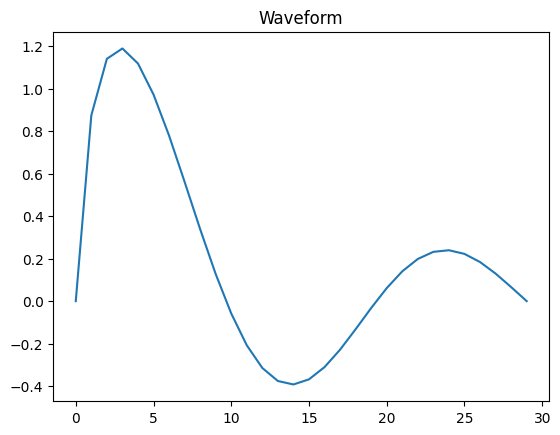

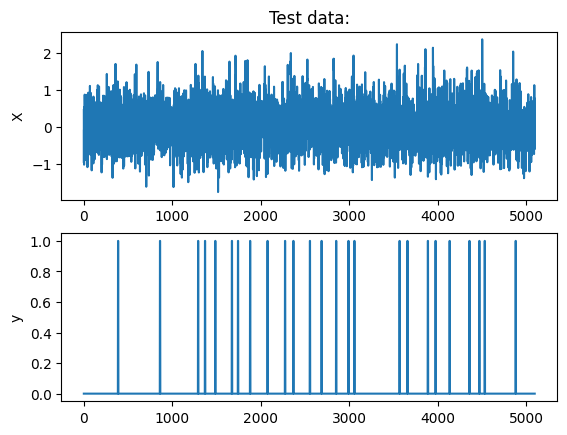

In [1]:

#%% load packages

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

#%%

#Prepare waveform data set container:
class waveFormDataset(torch.utils.data.Dataset):
    """waveFormDetectionDataset"""

    def __init__(self, waveforms, backgroundGenerator, targetRate=1):
        """
        Args:
            waveforms: array of size nxl, showing n different examples of target waveforms, length l
            backgroundGenerator: function, no input, outputs non-target signals, length L>l
        """

        if len(waveforms.shape)==0:
            waveforms=np.expand_dims(waveforms,0)

        self.ntargets=waveforms.shape[0]
        self.targets=waveforms
        self.backgroundGenerator=backgroundGenerator
        self.targetRate=targetRate

    def __len__(self):
        return 1000 #arbitrary

    def __getitem__(self, idx):
        #combines targets and backgroundGenerator. includes target in targetRate*100 percentage of outputs

        sample=self.backgroundGenerator()

        assert(len(sample)>=self.targets.shape[1])

        labels=sample*0

        if np.random.rand()<=self.targetRate:
            target=self.targets[np.random.randint(0,self.ntargets),:]
            target=torch.reshape(target,(-1,1))
            targetL=len(target)

            backgroundL=len(sample)

            endBuffer=4 #we need to ensure a bit of space at the end for placing 1-labels
            startIdx=np.random.randint(0,backgroundL-targetL-endBuffer,1)[0]
            sample[startIdx:(startIdx+targetL)]=sample[startIdx:(startIdx+targetL)]+target
            labels[startIdx+targetL+range(0,endBuffer)]=1


        return sample,labels

# %%

# setup dataset

#training:
targetL=30
waveform=np.sin(np.linspace(0,np.pi*3,targetL))/np.linspace(.2,5,targetL)
waveform=np.expand_dims(waveform,0)
waveform=torch.tensor(waveform,dtype=torch.float32)

def bgg():
    backgroundL=100
    scale=.5
    background=torch.tensor(np.random.normal(0,scale=scale,size=(backgroundL,1)),dtype=torch.float32)
    return background

wfDataset=waveFormDataset(waveform,bgg,.5)
e=wfDataset.__getitem__(1)
waveformLoader=torch.utils.data.DataLoader(wfDataset,batch_size=32)
# %%

#seed random number generator:
torch.manual_seed(1066)
np.random.seed(1066)

#test dataset:
nTest=50
testX,testy=wfDataset.__getitem__(1)

for iVal in range(nTest):
    x,y=wfDataset.__getitem__(1)
    testX=torch.cat((testX,x),0)
    testy=torch.cat((testy,y),0)


testX=torch.unsqueeze(testX,0)
print(f'Test input shape: {testX.shape}')
plt.plot(waveform[0,:])
plt.title('Waveform')
plt.figure()
plt.subplot(2,1,1)
plt.plot(testX[0,:])
plt.ylabel('X')
plt.title('Test data:')

plt.subplot(2,1,2)
plt.plot(testy[:,0])
plt.ylabel('y');

Epoch [1/200], Train Loss: 0.6258, Val Loss: 0.3324, Accuracy: 0.6549
Epoch [2/200], Train Loss: 0.1494, Val Loss: 0.1209, Accuracy: 0.9800
Epoch [3/200], Train Loss: 0.1126, Val Loss: 0.1137, Accuracy: 0.9809
Epoch [4/200], Train Loss: 0.1094, Val Loss: 0.1184, Accuracy: 0.9810
Epoch [5/200], Train Loss: 0.1111, Val Loss: 0.1139, Accuracy: 0.9806
Epoch [6/200], Train Loss: 0.1114, Val Loss: 0.1116, Accuracy: 0.9805
Epoch [7/200], Train Loss: 0.1093, Val Loss: 0.1114, Accuracy: 0.9806
Epoch [8/200], Train Loss: 0.1150, Val Loss: 0.1111, Accuracy: 0.9791
Epoch [9/200], Train Loss: 0.1080, Val Loss: 0.1105, Accuracy: 0.9804
Epoch [10/200], Train Loss: 0.1138, Val Loss: 0.1111, Accuracy: 0.9791
Epoch [11/200], Train Loss: 0.1097, Val Loss: 0.1093, Accuracy: 0.9800
Epoch [12/200], Train Loss: 0.1089, Val Loss: 0.1047, Accuracy: 0.9800
Epoch [13/200], Train Loss: 0.1084, Val Loss: 0.1070, Accuracy: 0.9796
Epoch [14/200], Train Loss: 0.1055, Val Loss: 0.1019, Accuracy: 0.9805
Epoch [15/200],

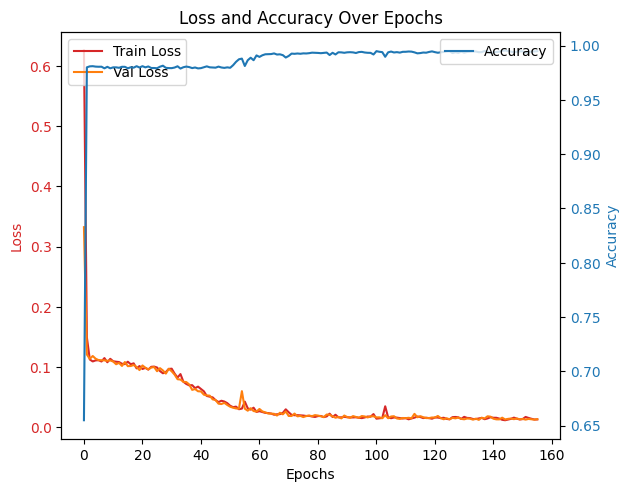

Average Test Loss: 0.0200


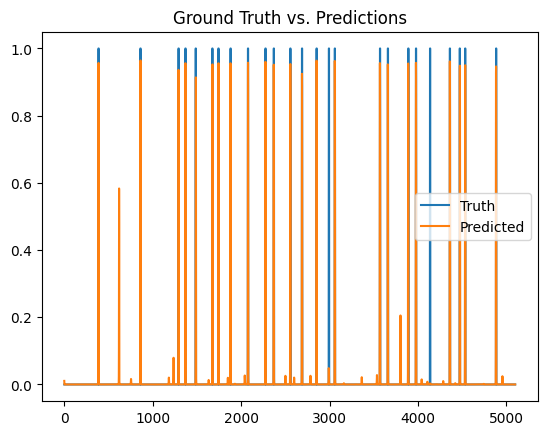

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Define the LSTM model
class WaveformDetector(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(WaveformDetector, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        h, _ = self.lstm(x)
        out = self.fc(h)
        out = self.sigmoid(out)
        return out

# Model parameters
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1

# Initialize model, loss function, and optimizer
model = WaveformDetector(input_size, hidden_size, num_layers, output_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# Early stopping parameters
patience = 20
min_delta = 1e-6
best_val_loss = np.inf
epochs_no_improve = 0

# Lists to store loss and accuracy over epochs
train_losses = []
val_losses = []
accuracies = []

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in waveformLoader:
        inputs, labels = inputs, labels.float()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate accuracy
        predictions = (outputs > 0.5).float()
        correct += (predictions == labels).sum().item()
        total += labels.numel()
    
    train_losses.append(train_loss / len(waveformLoader))
    accuracy = correct / total
    accuracies.append(accuracy)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in waveformLoader:
            inputs, labels = inputs, labels.float()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(waveformLoader)
    val_losses.append(avg_val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss / len(waveformLoader):.4f}, '
          f'Val Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}')
    
    # Early stopping check based on validation loss
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

# Plot Loss and Accuracy
fig, ax1 = plt.subplots()

# Loss plot
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(train_losses, label='Train Loss', color='tab:red')
ax1.plot(val_losses, label='Val Loss', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')

# Accuracy plot (secondary y-axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(accuracies, label='Accuracy', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.legend(loc='upper right')

fig.tight_layout()
plt.title("Loss and Accuracy Over Epochs")
plt.show()

# Evaluate on test data and plot predictions vs. ground truth
with torch.no_grad():
    test_outputs = model(testX)
    test_outputs = test_outputs.squeeze(0)  # Remove batch dimension to match testy
    test_loss = criterion(test_outputs, testy.float())
    print(f'Average Test Loss: {test_loss.item():.4f}')

    # Plot ground truth vs. predictions
    plt.plot(testy, label='Truth')
    plt.plot(test_outputs.squeeze().numpy(), label='Predicted')
    plt.legend()
    plt.title("Ground Truth vs. Predictions")
    plt.show()
